# Online Retail — Customer Return / Churn Prediction

Predicting whether a customer will make a purchase in the **future window** based on their behaviour in the **observation window**.

- **Dataset:** Online Retail II
- **Observation window:** transactions before `2010-08-31` → used to build features
- **Label window:** transactions on/after `2010-08-31` → used to build the target (`1` = customer returned)

This temporal split avoids leakage: features and target come from disjoint time periods.

**Pipeline:** load → clean → feature engineering → target → train/test split → baseline → models → evaluation.

## 1. Setup & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

In [2]:
# Boundary between the observation window (features) and the label window (target).
CUTOFF = pd.Timestamp("2010-08-31")
# Splits the observation window in half to measure a spending trend.
MID = pd.Timestamp("2010-04-15")

## 2. Load data

In [3]:
df = pd.read_excel("data/online_retail_II.xlsx")
df.shape

(525461, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Cleaning

Drop exact duplicate rows and transactions without a `Customer ID` (we need a customer to aggregate on).

In [5]:
df = df.drop_duplicates()
df = df.dropna(subset=["Customer ID"])
df.shape

(410763, 8)

## 4. Feature engineering

All features are computed **only** from the observation window (`InvoiceDate < CUTOFF`).

- `monetary` — total revenue
- `frequency` — number of distinct invoices
- `recency` — days since last purchase
- `tenure` — days since first purchase
- `cancel_rate` — share of cancelled lines (invoices starting with `C`)
- `n_products` — number of distinct products bought
- `trend` — 2nd-half spend minus 1st-half spend (momentum)

In [6]:
# Observation window: use .copy() so the derived columns below don't raise SettingWithCopyWarning.
df_obs = df[df["InvoiceDate"] < CUTOFF].copy()
df_obs["Revenue"] = df_obs["Quantity"] * df_obs["Price"]
df_obs["is_cancel"] = df_obs["Invoice"].astype(str).str.startswith("C")
df_obs.shape

(250422, 10)

In [7]:
grp = df_obs.groupby("Customer ID")

monetary = grp["Revenue"].sum()
frequency = grp["Invoice"].nunique()
recency = (CUTOFF - grp["InvoiceDate"].max()).dt.days
tenure = (CUTOFF - grp["InvoiceDate"].min()).dt.days
cancel_rate = grp["is_cancel"].mean()
n_products = grp["StockCode"].nunique()

In [8]:
# Spending trend: second half of the observation window vs. first half.
spend_h1 = df_obs[df_obs["InvoiceDate"] <  MID].groupby("Customer ID")["Revenue"].sum()
spend_h2 = df_obs[df_obs["InvoiceDate"] >= MID].groupby("Customer ID")["Revenue"].sum()

In [9]:
customers = pd.concat(
    [monetary, frequency, recency, tenure, cancel_rate, n_products], axis=1
)
customers.columns = [
    "monetary", "frequency", "recency", "tenure", "cancel_rate", "n_products"
]
customers["trend"] = (
    spend_h2.reindex(customers.index, fill_value=0)
    - spend_h1.reindex(customers.index, fill_value=0)
)
customers.head()

,monetary,frequency,recency,tenure,cancel_rate,n_products,trend
Customer ID,,,,,,,
12346.0,-46.24,13,61,259,0.232558,28,-300.34
12349.0,1244.37,3,104,269,0.096154,49,1292.67
12355.0,488.21,1,101,101,0.000000,22,488.21
12358.0,1697.93,2,84,265,0.000000,34,-1161.73
12359.0,1918.03,7,69,268,0.044444,82,-938.43


## 5. Target

A customer is labelled `1` (returned) if they appear in the label window (`InvoiceDate >= CUTOFF`).

In [10]:
returning_customers = df[df["InvoiceDate"] >= CUTOFF]["Customer ID"].unique()
customers["target"] = customers.index.isin(returning_customers).astype(int)

# Class balance (baseline to beat).
customers["target"].mean()

np.float64(0.6032496307237813)

## 6. Train / test split

In [11]:
X = customers.drop(columns="target")
y = customers["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, stratify=y
)
print(X_train.shape, X_test.shape)
print("train positive rate:", y_train.mean())
print("test  positive rate:", y_test.mean())

(2708, 7) (677, 7)
train positive rate: 0.603397341211226
test  positive rate: 0.6026587887740029


## 7. Baseline

`DummyClassifier` always predicts the majority class. Every real model has to beat this.

In [12]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.6026587887740029

## 8. Logistic Regression

Linear model inside a pipeline with `StandardScaler` (logistic regression needs scaled features).

In [13]:
logreg_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])
logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, logreg_pipeline.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.60      0.61      0.60       269
           1       0.74      0.74      0.74       408

    accuracy                           0.69       677
   macro avg       0.67      0.67      0.67       677
weighted avg       0.69      0.69      0.69       677

ROC-AUC: 0.7506013557839493


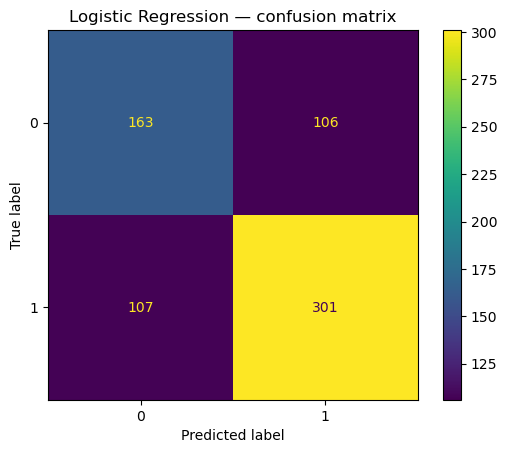

In [14]:
ConfusionMatrixDisplay.from_estimator(logreg_pipeline, X_test, y_test)
plt.title("Logistic Regression — confusion matrix")
plt.show()

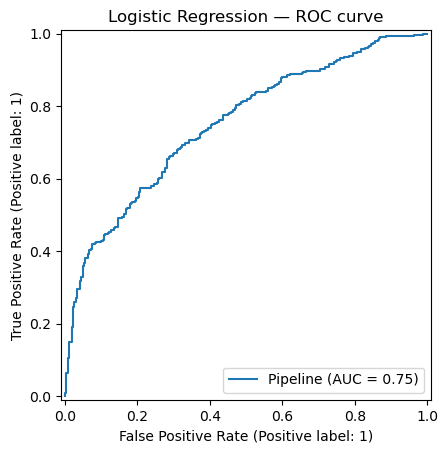

In [15]:
RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test)
plt.title("Logistic Regression — ROC curve")
plt.show()

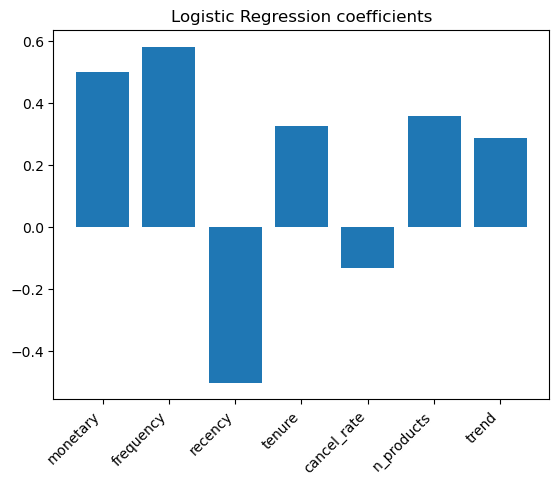

In [16]:
# Coefficients: sign/size shows how each feature pushes the return probability.
coefs = logreg_pipeline["model"].coef_[0]
plt.bar(X.columns, coefs)
plt.xticks(rotation=45, ha="right")
plt.title("Logistic Regression coefficients")
plt.show()

## 9. Tree ensembles (overfit check)

For the tree models we print **train and test** scores side by side. A large train-test gap = overfitting.

In [17]:
randforest = RandomForestClassifier(
    n_estimators=1000, random_state=23, max_depth=50, min_samples_leaf=2
)
randforest.fit(X_train, y_train)
print("Random Forest  train:", randforest.score(X_train, y_train))
print("Random Forest  test :", randforest.score(X_test, y_test))

Random Forest  train: 0.9745199409158051
Random Forest  test : 0.6322008862629247


In [18]:
xgb = XGBClassifier(random_state=23)
xgb.fit(X_train, y_train)
print("XGBoost  train:", xgb.score(X_train, y_train))
print("XGBoost  test :", xgb.score(X_test, y_test))

XGBoost  train: 0.9789512555391433
XGBoost  test : 0.6395864106351551


## 10. Model comparison

All models evaluated on the **same test set** with the same metrics.

In [19]:
def evaluate(model, name):
    return {
        "model": name,
        "train_acc": model.score(X_train, y_train),
        "test_acc": model.score(X_test, y_test),
        "test_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
    }

results = pd.DataFrame([
    evaluate(dummy, "Dummy"),
    evaluate(logreg_pipeline, "LogReg"),
    evaluate(randforest, "RandomForest"),
    evaluate(xgb, "XGBoost"),
]).set_index("model")
results

,train_acc,test_acc,test_auc
model,,,
Dummy,0.603397,0.602659,0.500000
LogReg,0.695347,0.685377,0.750601
RandomForest,0.974520,0.632201,0.720889
XGBoost,0.978951,0.639586,0.679464


## 11. Conclusions

- The **temporal train/test setup** (features before `CUTOFF`, target after) is the core of the project and avoids leakage.
- **Logistic Regression** is the most balanced model: it beats the dummy baseline and generalises (small train-test gap), and its coefficients are interpretable.
- **Random Forest** reaches very high train accuracy but a much lower test score → clear **overfitting** with these hyperparameters.
- **XGBoost** is too powerful a model for such a small dataset, so it overfits — its capacity is wasted here and hurts generalisation.